# Phase 9: Robustness and Generalization Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from pathlib import Path
from itertools import product
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact, binomtest
import sys

#Trying statsmodels for McNemar
try:
    from statsmodels.stats.contingency_tables import mcnemar as statsmodels_mcnemar
    STATSMODELS_AVAILABLE=True
except ImportError:
    STATSMODELS_AVAILABLE=False

warnings.filterwarnings('default')
np.random.seed(36)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

#Paths
PROJECT_ROOT=Path.cwd().parent
PHASE6_OUTPUT=PROJECT_ROOT / 'data' / 'processed' / 'phase6_models'
PHASE8_OUTPUT=PROJECT_ROOT / 'data' / 'processed' / 'phase8_structural_analysis'
PHASE9_OUTPUT=PROJECT_ROOT / 'data' / 'processed' / 'phase9_robustness'
PHASE9_OUTPUT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0,str(PROJECT_ROOT))        #To access util functions from src

#Constants
FDR_ALPHA=0.05
EFFECT_THRESHOLD_CONTINUOUS=0.10
EFFECT_THRESHOLD_FAILURE=0.01
MIN_SAMPLE_WARNING=10

DATASETS=['2007', '2008']
K_VALUES=[1, 3, 5, 10]
MODELS=['pointwise', 'pairwise', 'lightgbm']
PIPELINES=['raw', 'global', 'per_query']

#Baseline
BASELINE_MODEL='pointwise'
BASELINE_PIPELINE='raw'

warnings_issued=[]

print('='*80)
print('PHASE 9: ROBUSTNESS & GENERALIZATION VALIDATION')
print('='*80)
print(f'Output: {PHASE9_OUTPUT}')
print(f'Baseline: {BASELINE_MODEL}_{BASELINE_PIPELINE}')
print(f'McNemar: {"statsmodels" if STATSMODELS_AVAILABLE else "manual fallback"}')
print('='*80)

PHASE 9: ROBUSTNESS & GENERALIZATION VALIDATION
Output: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase9_robustness
Baseline: pointwise_raw
McNemar: statsmodels


## 2. Utility Functions

In [2]:
from src.utils import (
    make_fail_flag,
    bh_fdr,
    safe_k,
    check_sample_size,
    compute_failure_at_k,
    mcnemar_test
)

print("Utilities imported from src.ltr_utils")

make_fail_flag
bh_fdr
safe_k
check_sample_size
compute_failure_at_k
mcnemar_test

All utilities defined
Utilities imported from src.ltr_utils


## 3. Loading Phase 6 artifacts

In [3]:
print('\n'+'='*80)
print('LOADING PHASE 6 ARTIFACTS')
print('='*80)

def load_phase6_artifacts(dataset: str) -> dict:
    #Load Phase 6 with strict validation.
    artifacts={'query_metrics': {}, 'predictions': {}}
    for model, pipeline in product(MODELS, PIPELINES):
        key=f'{model}_{pipeline}_{dataset}'
        qm_file=PHASE6_OUTPUT / f'{key}_query_metrics.csv'
        pred_file=PHASE6_OUTPUT / f'{key}_predictions.csv'
        
        if not qm_file.exists():
            raise RuntimeError(f'MISSING: {qm_file}')
        if not pred_file.exists():
            raise RuntimeError(f'MISSING: {pred_file}')
        
        qm=pd.read_csv(qm_file)
        pred=pd.read_csv(pred_file)
        
        #Validating columns
        for col in ['qid', 'num_docs', 'num_relevant_1', 'Failure@5_primary']:
            if col not in qm.columns:
                raise RuntimeError(f'Missing "{col}" in {qm_file}')
        for col in ['qid', 'label', 'score']:
            if col not in pred.columns:
                raise RuntimeError(f'Missing "{col}" in {pred_file}')
        
        #Coercing dtypes
        qm['qid']=qm['qid'].astype(int)
        pred['qid']=pred['qid'].astype(int)
        pred['label']=pred['label'].astype(int)
        pred['score']=pred['score'].astype(float)
        
        artifacts['query_metrics'][key]=qm
        artifacts['predictions'][key]=pred
        print(f'{key:35s} ({len(qm)} queries, {len(pred)} docs)')
    return artifacts

artifacts_2007=load_phase6_artifacts('2007')
artifacts_2008=load_phase6_artifacts('2008')
all_artifacts={'2007': artifacts_2007, '2008': artifacts_2008}

print(f'\nLoaded artifacts for {len(DATASETS)} datasets')
print('='*80)


LOADING PHASE 6 ARTIFACTS
pointwise_raw_2007                  (336 queries, 13652 docs)
pointwise_global_2007               (336 queries, 13652 docs)
pointwise_per_query_2007            (336 queries, 13652 docs)
pairwise_raw_2007                   (336 queries, 13652 docs)
pairwise_global_2007                (336 queries, 13652 docs)
pairwise_per_query_2007             (336 queries, 13652 docs)
lightgbm_raw_2007                   (336 queries, 13652 docs)
lightgbm_global_2007                (336 queries, 13652 docs)
lightgbm_per_query_2007             (336 queries, 13652 docs)
pointwise_raw_2008                  (156 queries, 2874 docs)
pointwise_global_2008               (156 queries, 2874 docs)
pointwise_per_query_2008            (156 queries, 2874 docs)
pairwise_raw_2008                   (156 queries, 2874 docs)
pairwise_global_2008                (156 queries, 2874 docs)
pairwise_per_query_2008             (156 queries, 2874 docs)
lightgbm_raw_2008                   (156 queries,

## 4. Cross Dataset Persistent Structure

In [4]:
print('\n'+'='*80)
print('CROSS-DATASET PERSISTENT STRUCTURE')
print('='*80)
print('Persistent=intersection of failures across all 9 configs')
print('='*80)

def compute_persistent_queries(qm_dict: dict, dataset: str) -> dict:
    expected=len(MODELS)*len(PIPELINES)
    if len(qm_dict)!=expected:
        raise RuntimeError(f'{dataset}: Expected {expected} configs,found {len(qm_dict)}')

    evaluable_sets={}
    failure_sets={}
    for key, qm in qm_dict.items():
        evaluable_sets[key]=set(qm.loc[qm['num_relevant_1'] > 0, 'qid'].values)
        fail_flag=make_fail_flag(qm['Failure@5_primary'])
        fail_mask=(qm['num_relevant_1'] > 0) & (fail_flag == 1)
        failure_sets[key]=set(qm.loc[fail_mask, 'qid'].values)
    
    all_evaluable=set.intersection(*evaluable_sets.values())
    persistent=set.intersection(*failure_sets.values())
    all_failing=set.union(*failure_sets.values())
    
    pct_of_failing=100*len(persistent)/len(all_failing) if len(all_failing) > 0 else 0.0
    pct_of_evaluable=100*len(persistent)/len(all_evaluable) if len(all_evaluable) > 0 else 0.0
    
    check_sample_size(f'{dataset} persistent', len(persistent))
    
    return {
        'dataset': dataset,
        'n_evaluable': len(all_evaluable),
        'n_persistent': len(persistent),
        'n_failing': len(all_failing),
        'pct_persistent_of_failing': pct_of_failing,
        'pct_persistent_of_evaluable': pct_of_evaluable,
        'persistent_qids': persistent,
        'evaluable_qids': all_evaluable,
        'all_failing_qids': all_failing
    }

persistent_2007=compute_persistent_queries(artifacts_2007['query_metrics'], '2007')
persistent_2008=compute_persistent_queries(artifacts_2008['query_metrics'], '2008')

cross_df=pd.DataFrame([
    {k: v for k, v in persistent_2007.items() if not k.endswith('_qids')},
    {k: v for k, v in persistent_2008.items() if not k.endswith('_qids')}
])

print('\nCross-Dataset:')
display(cross_df)

#Statistical test
n_p2007=persistent_2007['n_persistent']
n_e2007=persistent_2007['n_evaluable']
n_p2008=persistent_2008['n_persistent']
n_e2008=persistent_2008['n_evaluable']

contingency=[[n_p2007, n_e2007 - n_p2007], [n_p2008, n_e2008 - n_p2008]]
if min(n_p2007, n_e2007 - n_p2007, n_p2008, n_e2008 - n_p2008) >= 5:
    _, pval, _, _ = chi2_contingency(contingency)
    test='chi2'
else:
    _, pval=fisher_exact(contingency)
    test='fisher'

print(f'\n{test}: p={pval:.4f}')
if pval < FDR_ALPHA:
    print('-> Rates DIFFER significantly')
else:
    print('-> No significant difference')

cross_df.to_csv(PHASE9_OUTPUT / 'phase9_persistent_cross_dataset.csv', index=False)
print('\nSaved: phase9_persistent_cross_dataset.csv')


CROSS-DATASET PERSISTENT STRUCTURE
Persistent=intersection of failures across all 9 configs
2008 persistent has 4 samples (< 10) -> unstable

Cross-Dataset:


,dataset,n_evaluable,n_persistent,n_failing,pct_persistent_of_failing,pct_persistent_of_evaluable
0,2007,290,22,85,25.8824,7.5862
1,2008,105,4,30,13.3333,3.8095



fisher: p=0.2510
-> No significant difference

Saved: phase9_persistent_cross_dataset.csv


When we compare MQ2007 and MQ2008, the persistent failure phenomenon clearly exists in both datasets. In MQ2007, we see 22 persistent queries out of 290 evaluable ones (about 7.6%). In MQ2008, there are 4 persistent queries out of 105 evaluable (about 3.8%). So the phenomenon does not disappear when we move to another dataset. It means persistent failures are not just some weird artifact of MQ2007.

At the same time, the magnitude is smaller in MQ2008. The percentage of persistent queries among failing queries drops from roughly 25.9% in MQ2007 to 13.3% in MQ2008. So numerically, MQ2008 looks less severe. But when we ran Fisher’s exact test, the p-value came out to 0.2510. That means we do not have statistical evidence that the rates are different across datasets. It doesn’t prove they are equal, it just means we cannot confidently say they differ with this sample size.

persistent ranking failures appear in both datasets, which supports the idea that the phenomenon is structurally real and not dataset-specific. However, the magnitude seems smaller in MQ2008, and due to the small persistent sample size there, we cannot draw strong conclusions about cross-dataset differences. So the effect replicates, but the strength of it may vary.

## 5. Threshold and K Sensitivity


THRESHOLD & K SENSITIVITY

Sensitivity:


,dataset,k,relevance_threshold,n_evaluable,n_failures,pct_failures
0,2007,1,1,290,135,46.5517
1,2007,1,2,151,101,66.8874
2,2007,3,1,290,73,25.1724
3,2007,3,2,151,63,41.7219
4,2007,5,1,290,44,15.1724
5,2007,5,2,151,48,31.7881
6,2007,10,1,290,24,8.2759
7,2007,10,2,151,23,15.2318
8,2008,1,1,105,43,40.9524
9,2008,1,2,63,31,49.2063



Saved: phase9_threshold_sensitivity.csv


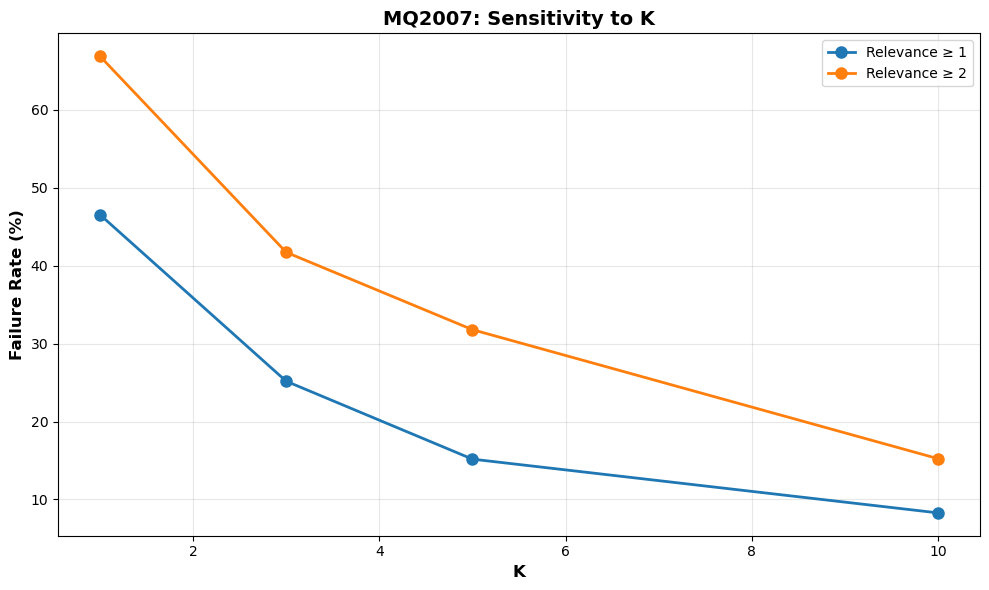

Saved: phase9_threshold_sensitivity_2007.png


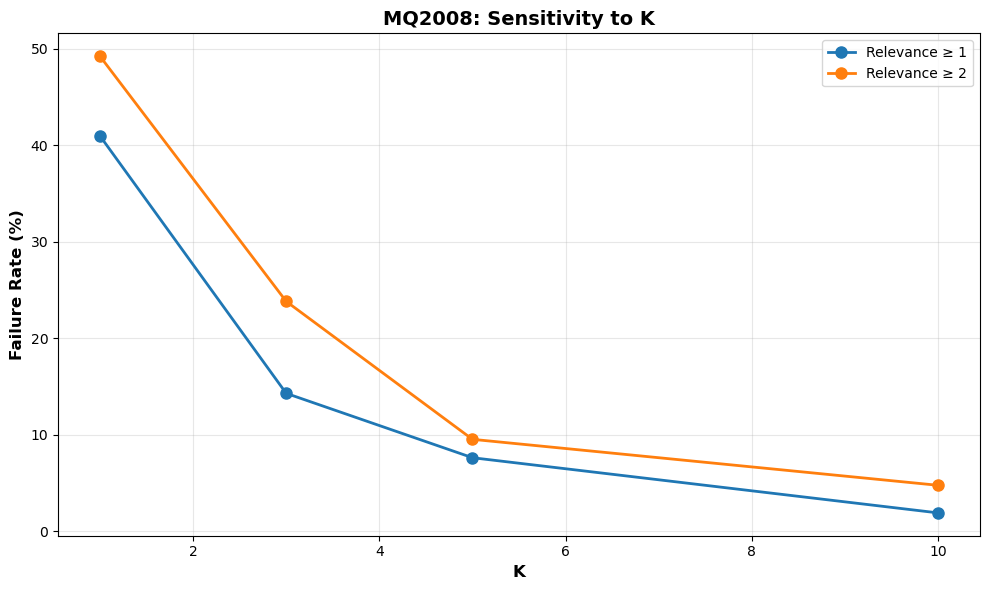

Saved: phase9_threshold_sensitivity_2008.png


In [6]:
print('\n'+'='*80)
print('THRESHOLD & K SENSITIVITY')
print('='*80)

sensitivity_results=[]
for dataset in DATASETS:
    baseline_key=f'{BASELINE_MODEL}_{BASELINE_PIPELINE}_{dataset}'
    pred_df=all_artifacts[dataset]['predictions'][baseline_key]
    for k in K_VALUES:
        for rel_thresh in [1, 2]:
            failures=compute_failure_at_k(pred_df, k, rel_thresh)
            evaluable=[q for q, v in failures.items() if v['evaluable']]
            failing=[q for q, v in failures.items() if v['evaluable'] and v['failure']==1]
            n_eval=len(evaluable)
            n_fail=len(failing)
            pct=100 * n_fail / n_eval if n_eval > 0 else 0.0
            sensitivity_results.append({
                'dataset': dataset,
                'k': k,
                'relevance_threshold': rel_thresh,
                'n_evaluable': n_eval,
                'n_failures': n_fail,
                'pct_failures': pct
            })

sens_df=pd.DataFrame(sensitivity_results).sort_values(['dataset', 'k', 'relevance_threshold'])
print('\nSensitivity:')
display(sens_df)

sens_df.to_csv(PHASE9_OUTPUT / 'phase9_threshold_sensitivity.csv', index=False)
print('\nSaved: phase9_threshold_sensitivity.csv')

#Plots
for dataset in DATASETS:
    fig, ax=plt.subplots(figsize=(10, 6))
    sub=sens_df[sens_df['dataset'] == dataset]
    for rel_thresh in [1, 2]:
        data=sub[sub['relevance_threshold']==rel_thresh]
        ax.plot(data['k'], data['pct_failures'], marker='o', linewidth=2,
                label=f'Relevance ≥ {rel_thresh}', markersize=8)
    ax.set_xlabel('K', fontsize=12, fontweight='bold')
    ax.set_ylabel('Failure Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'MQ{dataset}: Sensitivity to K', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PHASE9_OUTPUT / f'phase9_threshold_sensitivity_{dataset}.png', dpi=150)
    plt.show()
    print(f'Saved: phase9_threshold_sensitivity_{dataset}.png')

When we look at how failure changes with K, the pattern is actually very clean and intuitive. For both MQ2007 and MQ2008, failure rates consistently decrease as K increases from 1 -> 3 -> 5 -> 10. That is exactly what we would expect. If we allow the model to return more documents, it naturally has more chances to include at least one relevant document, so "failure" becomes less frequent. 

For example, in MQ2007 with relevance >= 1, failure drops from about **46.6% at K=1** to **8.3% at K=10**. MQ2008 shows the same smooth decline, from **41.0% at K=1** to just **1.9% at K=10**. There’s no strange spikes or irregular jumps, which is reassuring. The behavior looks stable and predictable.

Now when we tighten the relevance definition from >= 1 to >= 2, things become harder, as expected. Fewer queries are even evaluable under the stricter threshold (for instance, MQ2007 drops from 290 evaluable queries to 151). Within that smaller set, failure rates are generally higher. That makes sense because we are now asking the model to retrieve *highly* relevant documents, not just moderately relevant ones. At K=5 in MQ2007, failure jumps from **15.2% (>=1)** to **31.8% (>=2)**, which is quite a noticeable increase. It suggests that while the model often retrieves *some* relevant document, it struggles more to rank the strongest ones near the top.

One important observation is that by K=10, failure becomes very small in both datasets, especially MQ2008. That means the baseline model is rarely completely missing relevance - the issue seems more about ranking strength at very small K rather than total absence of relevant documents. In other words, the failure problem is mostly a top-rank concentration issue, not a total retrieval breakdown.

Across datasets, MQ2008 generally shows lower failure rates than MQ2007 under the same settings. we would be careful not to immediately conclude that MQ2008 is "easier," since there are differences in query counts and label distributions. But numerically, the baseline appears to fail less often in MQ2008 Fold1.